<a href="https://colab.research.google.com/github/anwaruddin1/Bioinformatics-Workshop/blob/main/02_scRNAseq_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marker Analysis and Cell Annotation

In [1]:
untar("R_library.tar.gz")
#list.files("library")

In [2]:
# change the R library directory into './library'
.libPaths("library")

In [3]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [4]:
obj40 <- readRDS(file = "obj_combined.integrated_40res.rds")
obj40

An object of class Seurat 
44779 features across 1868 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, umap, tsne

In [5]:
DefaultAssay(obj40) <- "SCT"

## Find markers for every cluster compared to all remaining cells, report only the positive ones
Prior to performing differential expression, we first run PrepSCTFindMarkers, which ensures that the fixed value is set properly.

In [6]:
obj40 <- PrepSCTFindMarkers(obj40)

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 2045.95476398253



In [7]:
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.markers <- FindAllMarkers(obj40, only.pos = TRUE, min.pct = 0.30, logfc.threshold = 0.30, recorrect_umi = FALSE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7



## Now lets generate heatmap and dotplot for each of the clusters.

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: CDKN2A, KCNB2, NRCAM, FDCSP, ENSG00000248515, SFRP1, NTRK2, CALML5, GNGT1”


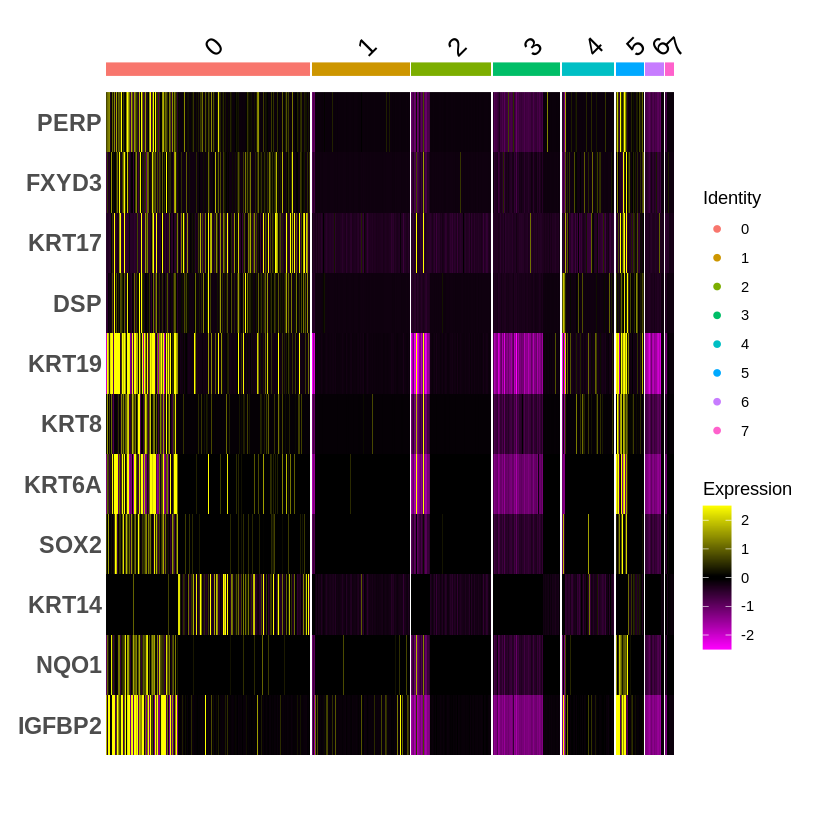

In [8]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_0.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster0.markers <- obj40.markers %>% filter(cluster==0) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

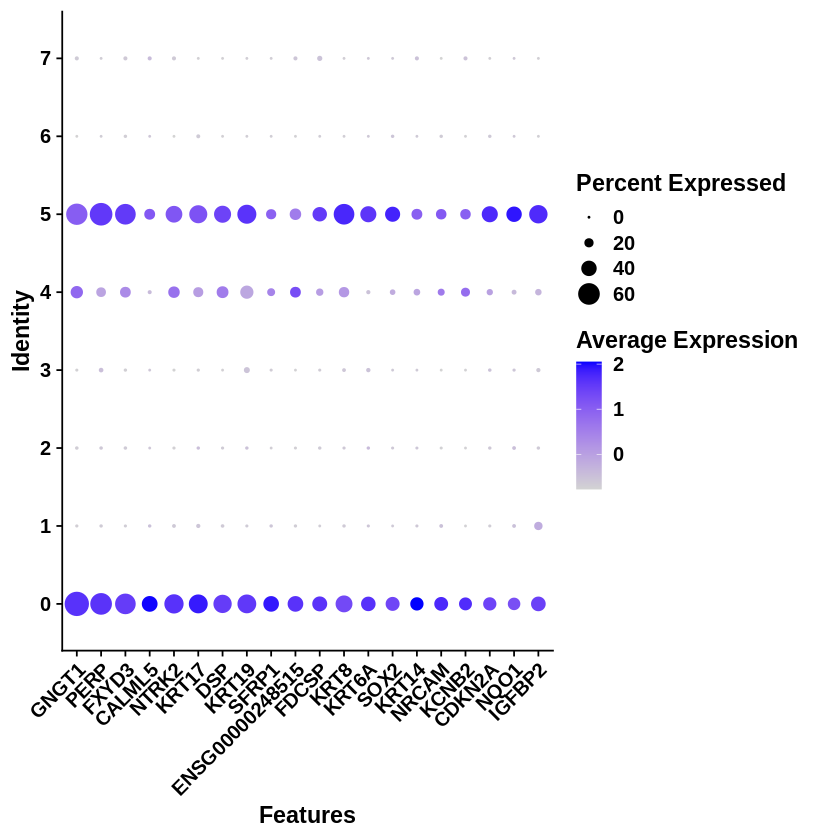

In [9]:

## Dotplot for Cluster_0
obj40.cluster0.markers$gene %>% write.table("obj40.cluster0.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster0.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PRSS23, PCOLCE, MMP2”


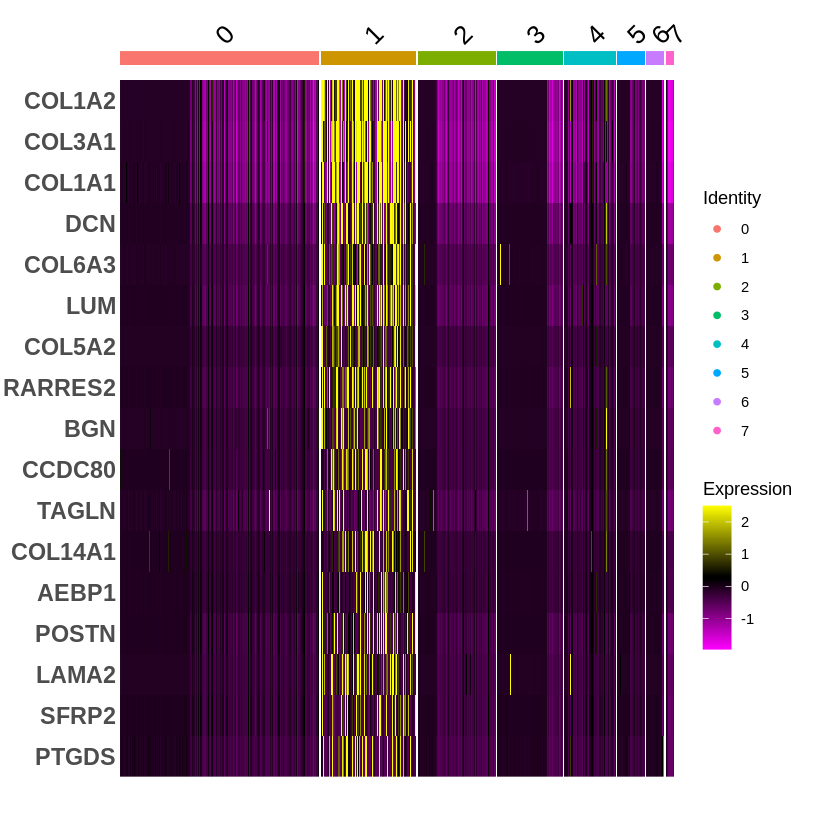

In [10]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_1.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster1.markers <- obj40.markers %>% filter(cluster==1) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))


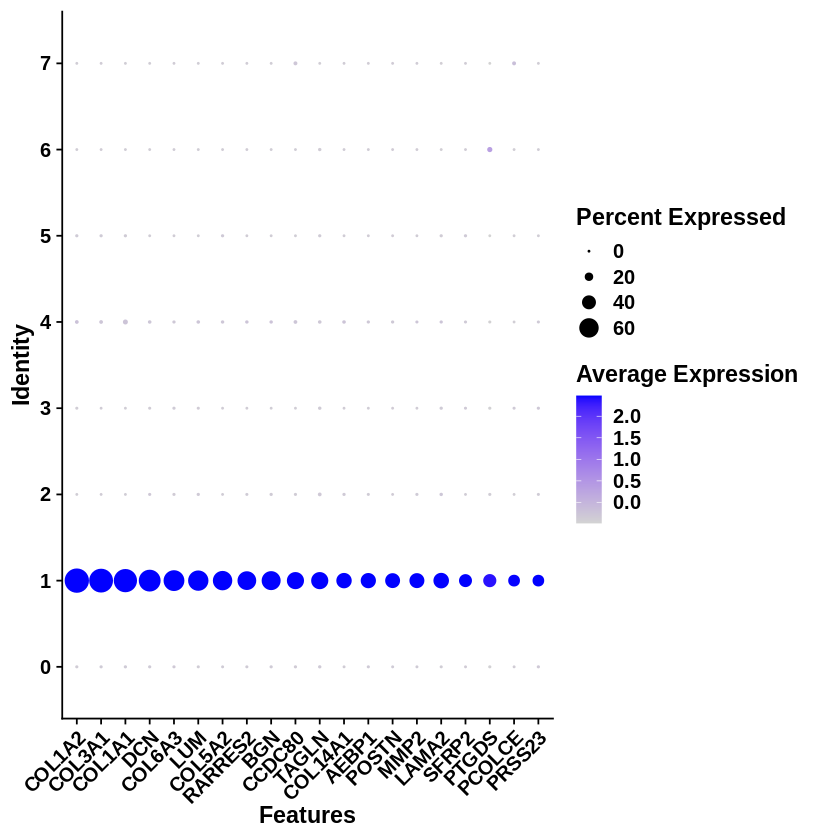

In [11]:
## Dotplot for Cluster_1
obj40.cluster1.markers$gene %>% write.table("obj40.cluster1.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster1.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: SPI1, MS4A4A, FCGR2A, CLEC7A, CD68”


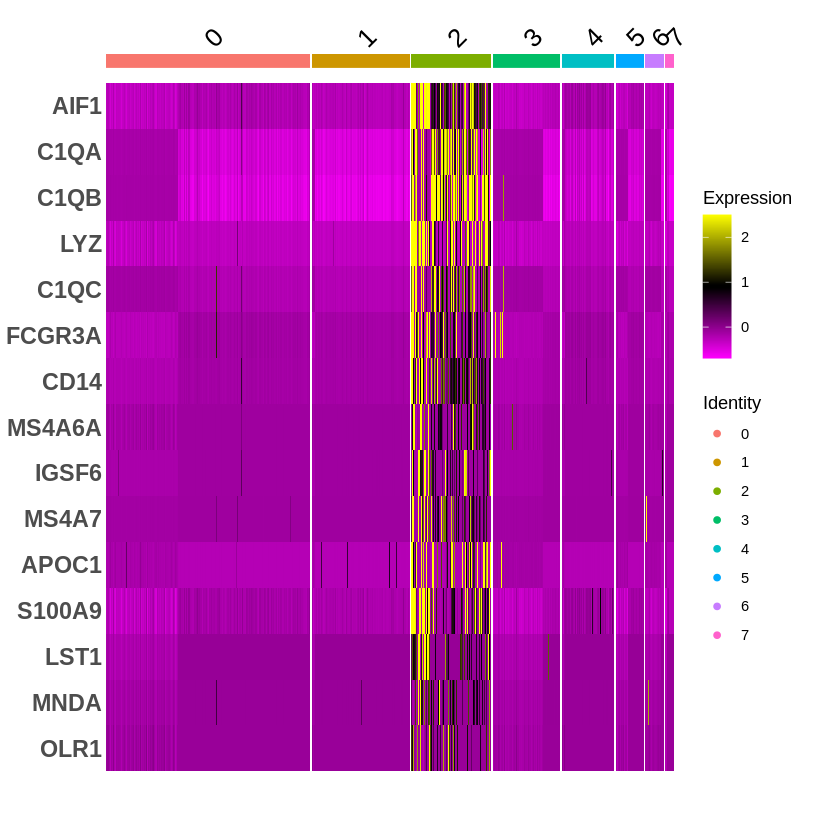

In [12]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_2.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster2.markers <- obj40.markers %>% filter(cluster==2) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

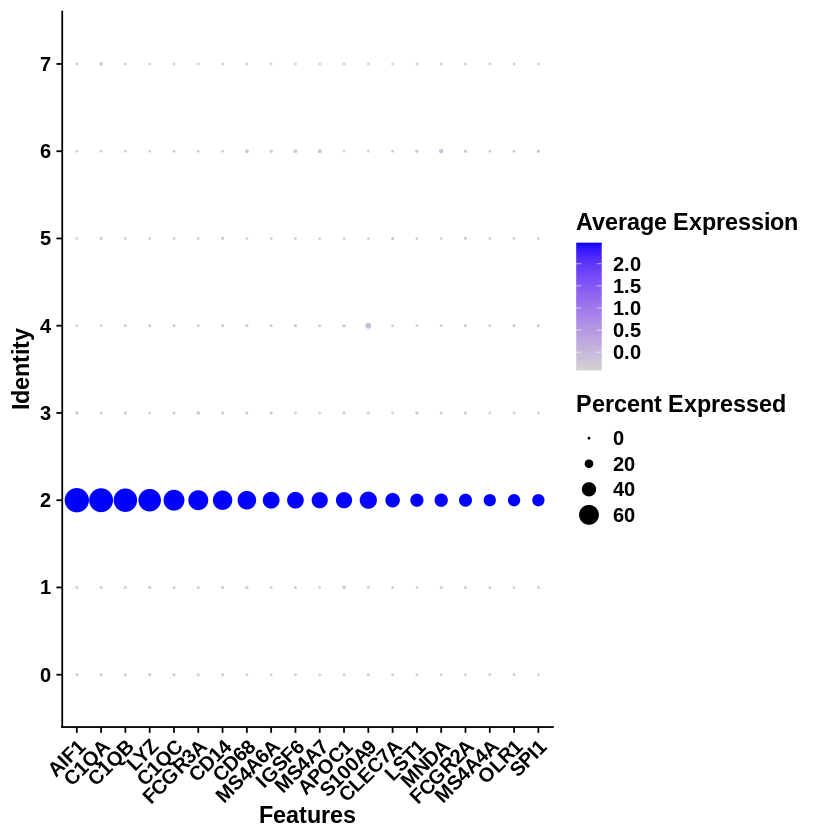

In [13]:
## Dotplot for Cluster_2
obj40.cluster2.markers$gene %>% write.table("obj40.cluster2.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster2.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

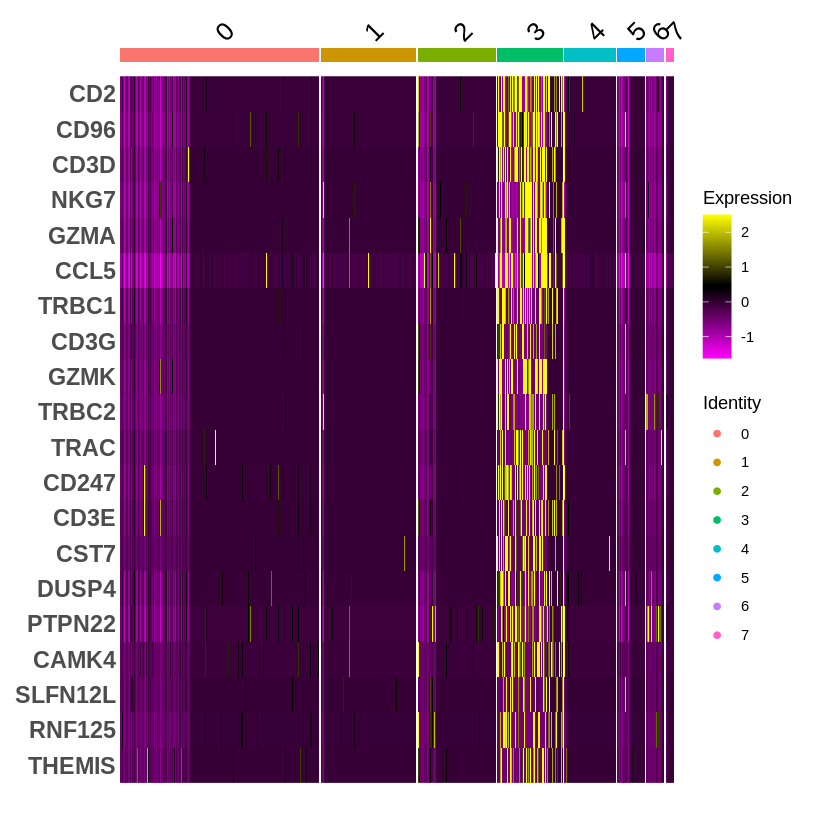

In [14]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_3.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster3.markers <- obj40.markers %>% filter(cluster==3) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster3.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

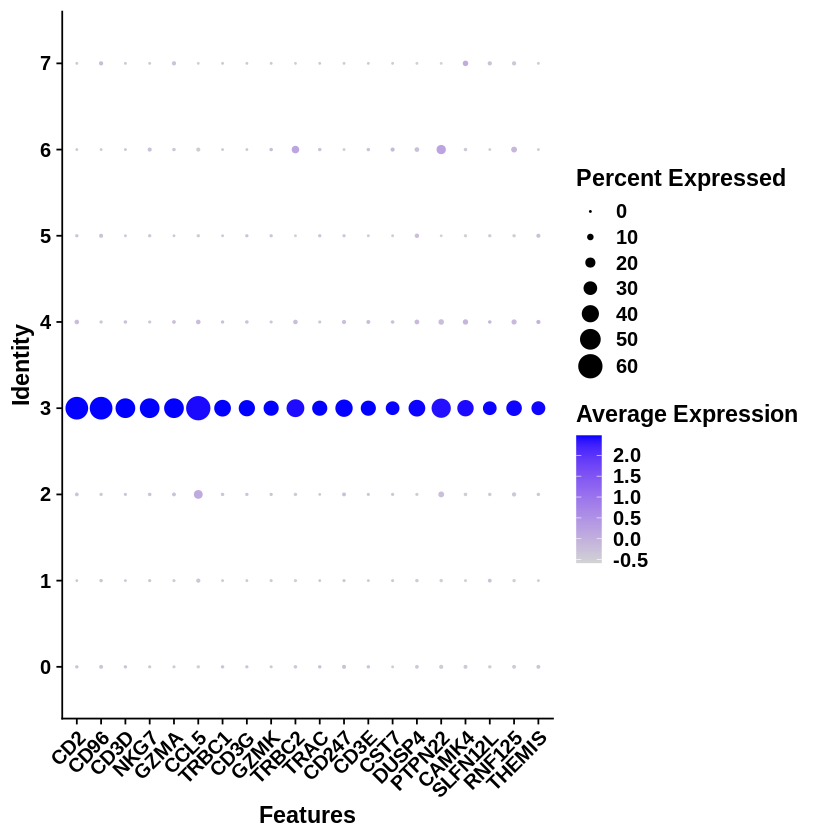

In [15]:
## Dotplot for Cluster_3
obj40.cluster3.markers$gene %>% write.table("obj40.cluster3.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster3.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PTPN13, TDRP, CYB5A, NFIA, PPP1R13B, ERRFI1, EPB41L5, GCNT2, CDH1, MYO6, MAGI3, MECOM, LMO7, NEDD4L, SFTPB”


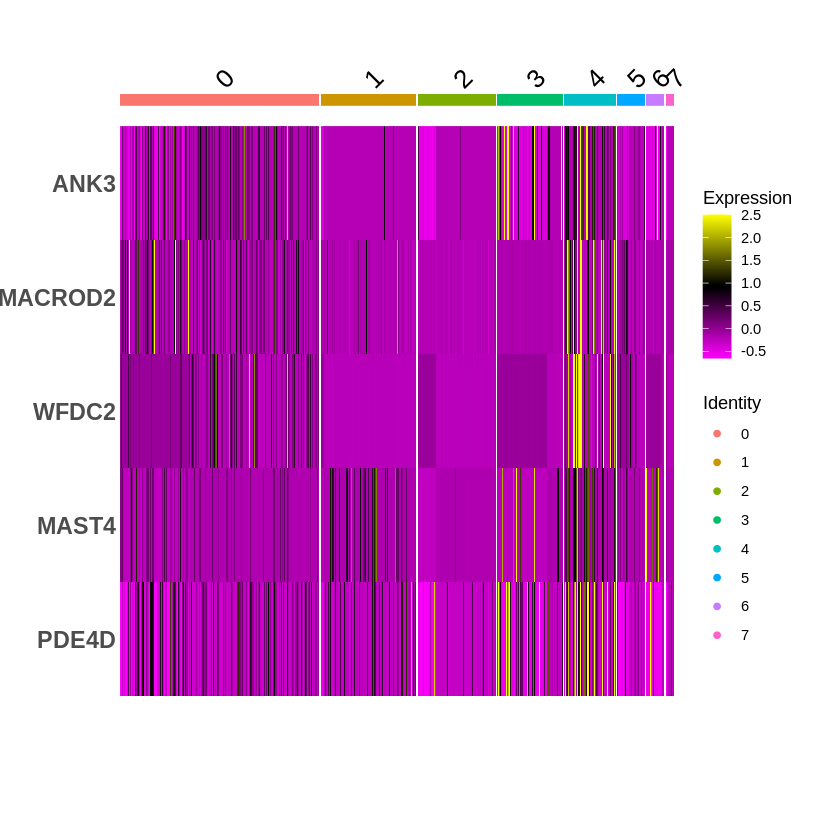

In [16]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_4.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster4.markers <- obj40.markers %>% filter(cluster==4) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

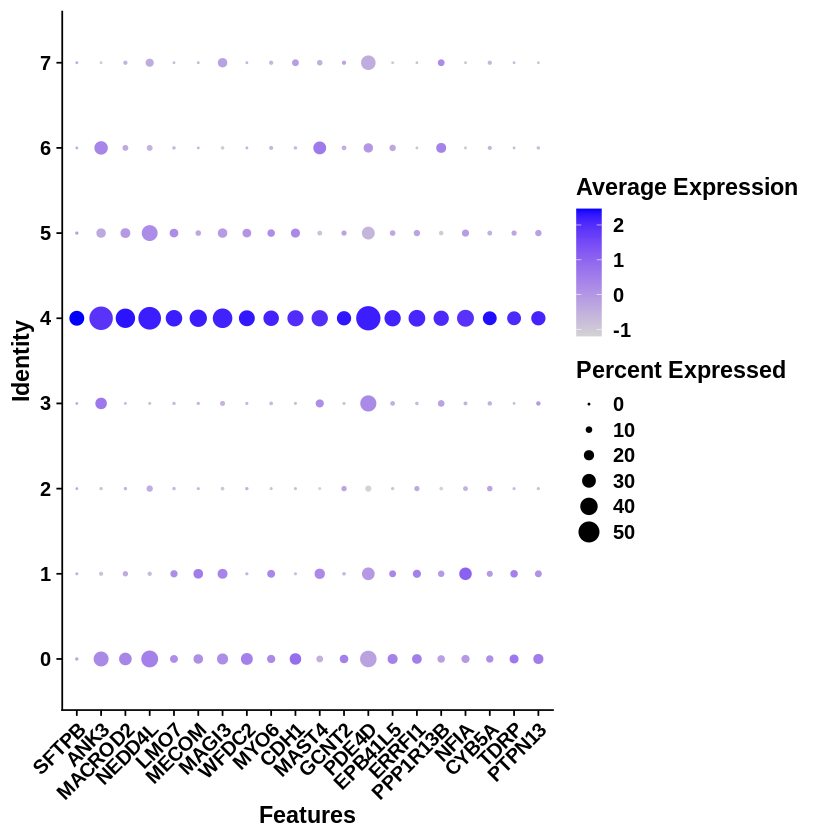

In [17]:
## Dotplot for Cluster_4
obj40.cluster4.markers$gene %>% write.table("obj40.cluster4.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster4.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: H1-1, TMEM106C, ECT2, CCNB1, PTTG1, CENPE, MAD2L1, NUSAP1, CKS1B, ASPM, GTSE1, MKI67, UBE2C, TPX2”


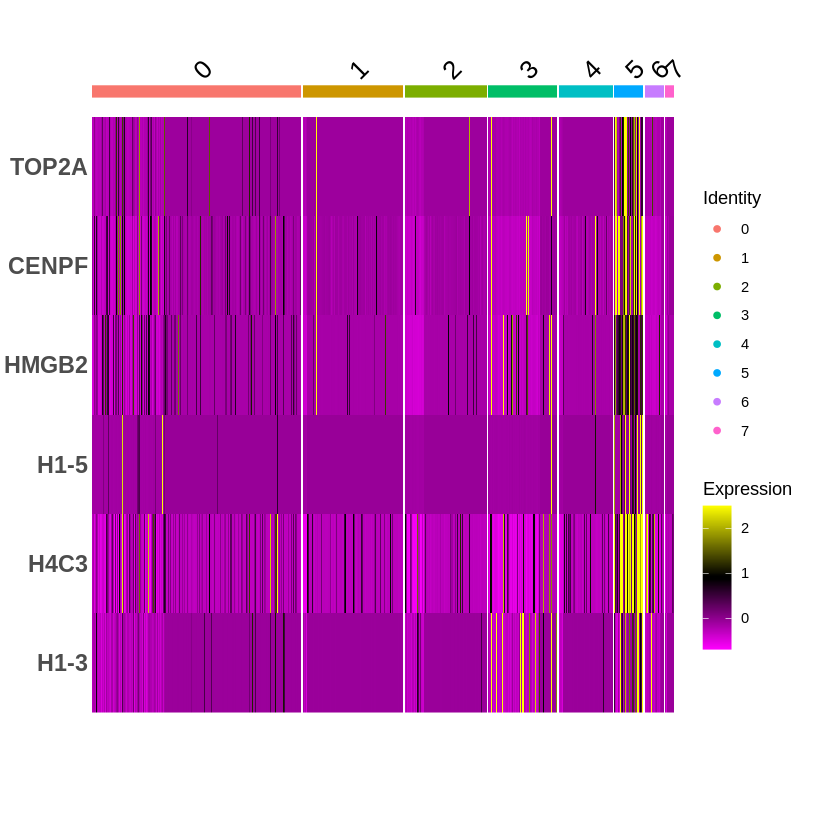

In [18]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_5.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster5.markers <- obj40.markers %>% filter(cluster==5) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

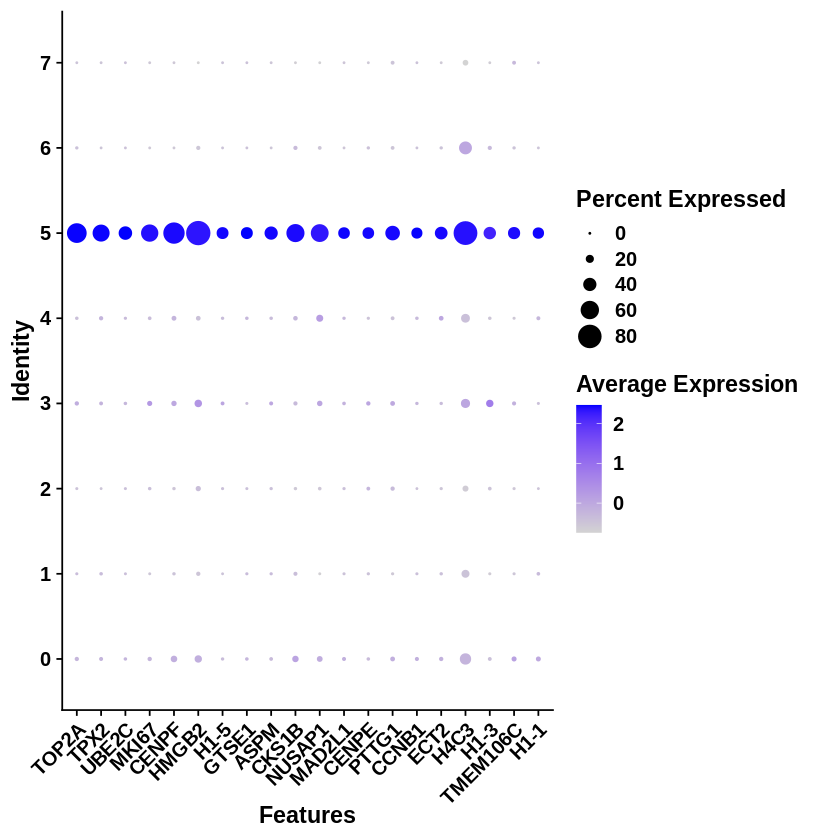

In [19]:
## Dotplot for Cluster_5
obj40.cluster5.markers$gene %>% write.table("obj40.cluster5.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster5.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TNFRSF13C, CD79B, PAX5, MS4A1”


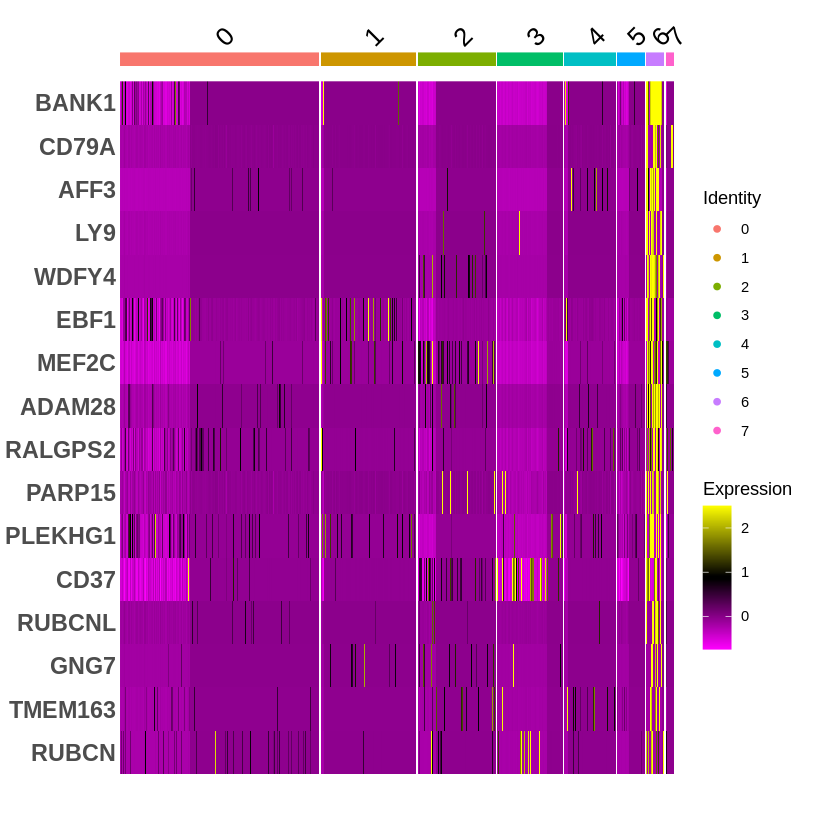

In [20]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_6.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster6.markers <- obj40.markers %>% filter(cluster==6) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

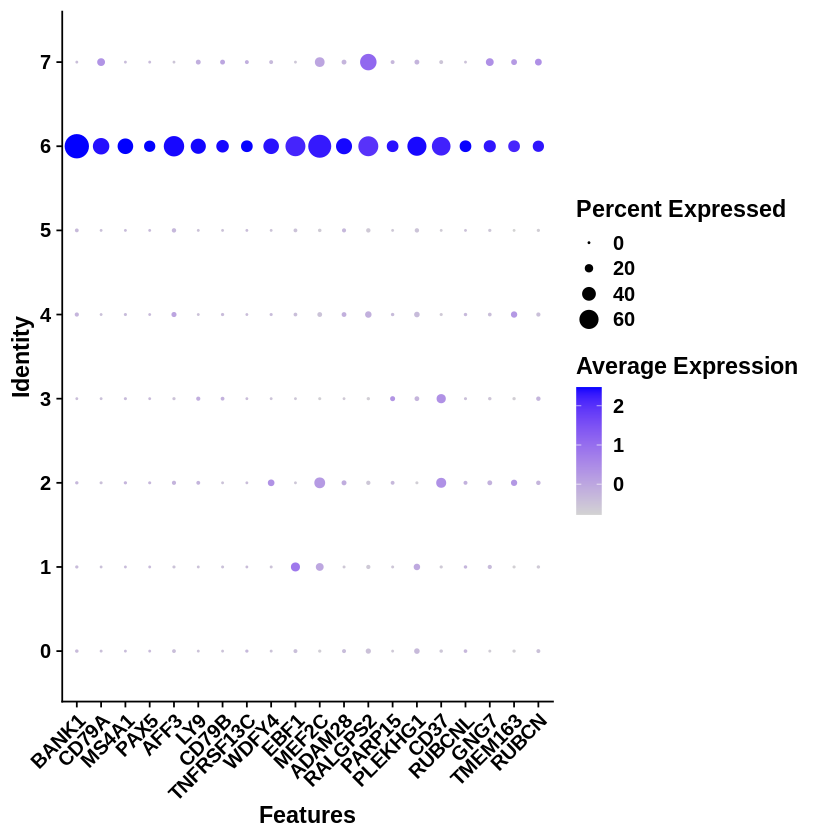

In [21]:
## Dotplot for Cluster_6
obj40.cluster6.markers$gene %>% write.table("obj40.cluster6.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster6.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TMEM107, BCAR3, SEC11C, TXNDC5, FKBP11, ANKRD36BP2, FCRL5, IGHG2, IGHG3, IGHG4”


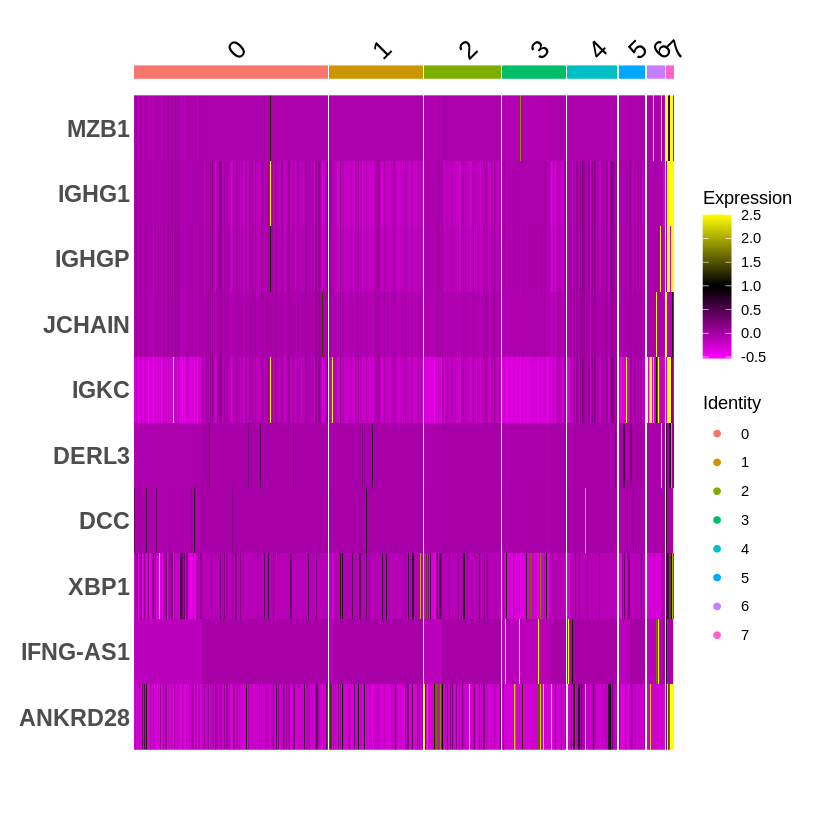

In [22]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_7.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster7.markers <- obj40.markers %>% filter(cluster==7) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

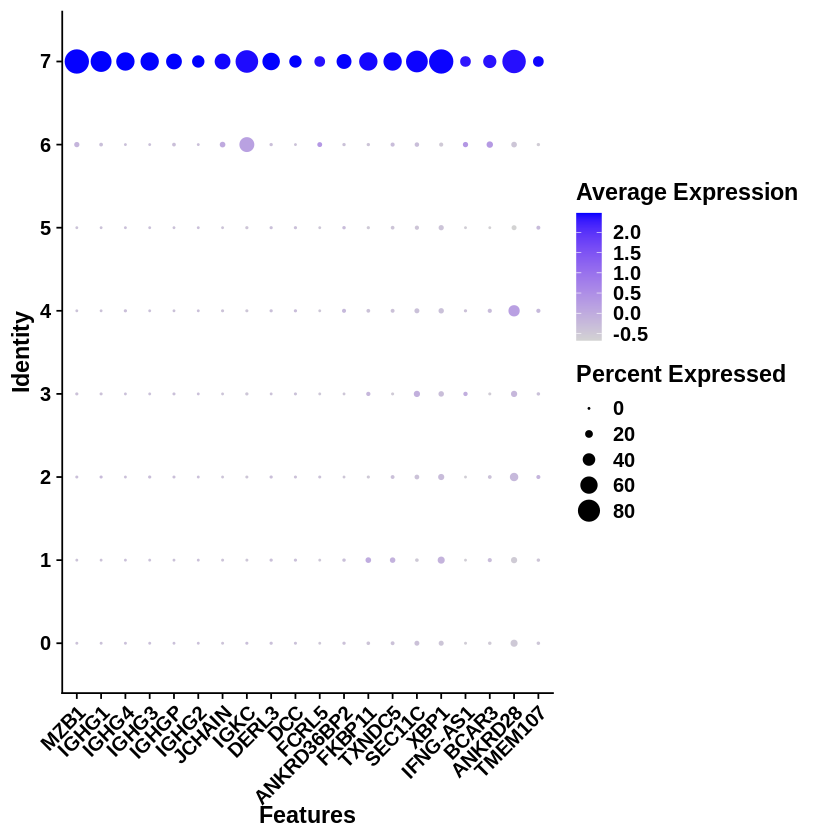

In [23]:
## Dotplot for Cluster_7
obj40.cluster7.markers$gene %>% write.table("obj40.cluster7.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster7.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))


## Aggregated average gene expression across clusters for the top 3 marker genes together plotted as heatmap

In [24]:
DefaultAssay(obj40) <- "RNA"
obj40 <- NormalizeData(obj40)
obj40.averages <- Seurat::AverageExpression(obj40, return.seurat=TRUE, assays = "RNA", layer = "data")

Normalizing layer: counts

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `ident` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
Centering and scaling data matrix



In [25]:
top_3_genes <- obj40.markers %>% group_by(cluster) %>% top_n(n = 3, wt = avg_log2FC)
top_3_genes

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2.367072e-98,3.935531,0.411,0.030,4.643722e-94,0,CALML5
1.127403e-70,3.424133,0.371,0.053,2.211740e-66,0,KRT6A
4.218057e-66,3.801264,0.332,0.041,8.274984e-62,0,KRT14
1.045085e-279,8.995782,0.760,0.008,2.050249e-275,1,COL3A1
9.401689e-154,9.125191,0.435,0.003,1.844423e-149,1,POSTN
6.465251e-127,8.992126,0.365,0.003,1.268353e-122,1,SFRP2
3.058850e-277,8.854426,0.743,0.006,6.000851e-273,2,C1QA
1.086072e-273,9.380992,0.729,0.004,2.130656e-269,2,C1QB
1.362672e-119,8.741417,0.327,0.001,2.673289e-115,2,MS4A4A


Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`).”


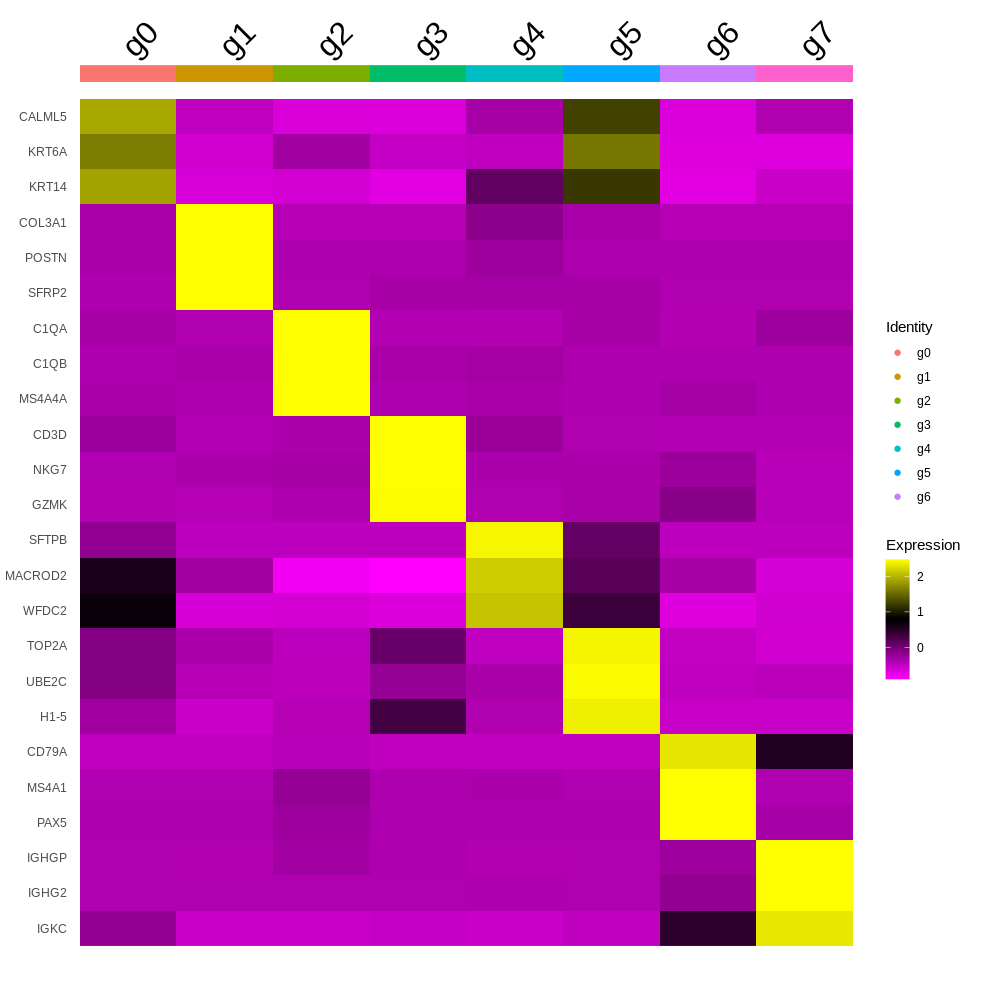

In [26]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
DoHeatmap(obj40.averages, features = as.character(c(top_3_genes$gene)), slot = "scale.data", draw.lines = FALSE, size = 8)

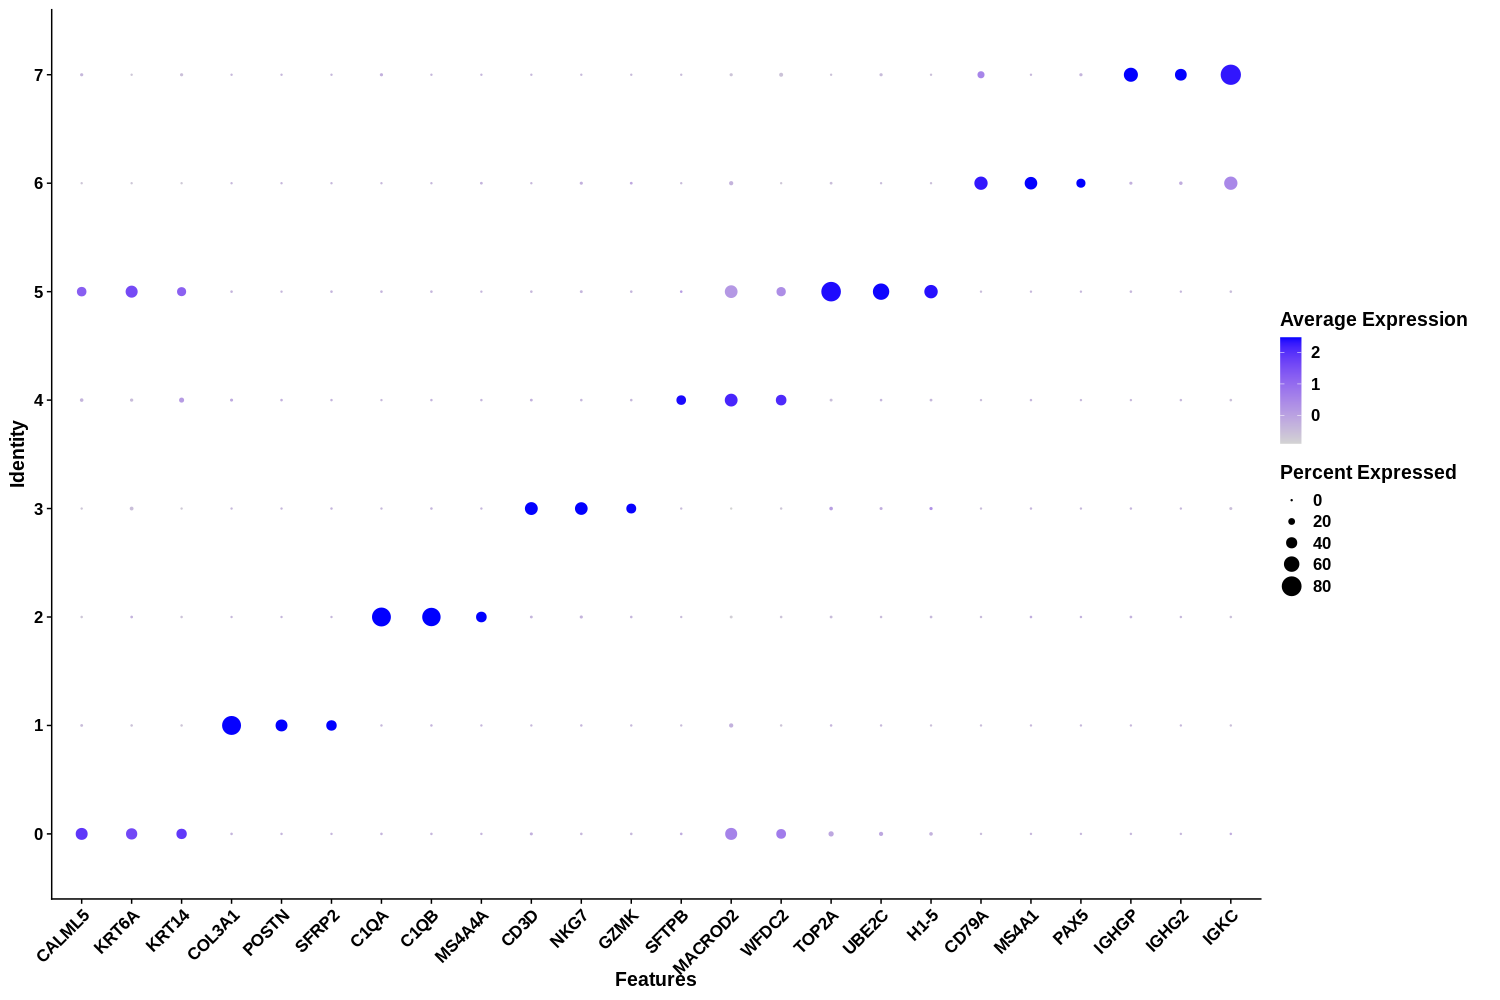

In [27]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
DotPlot(obj40, features = c(top_3_genes$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

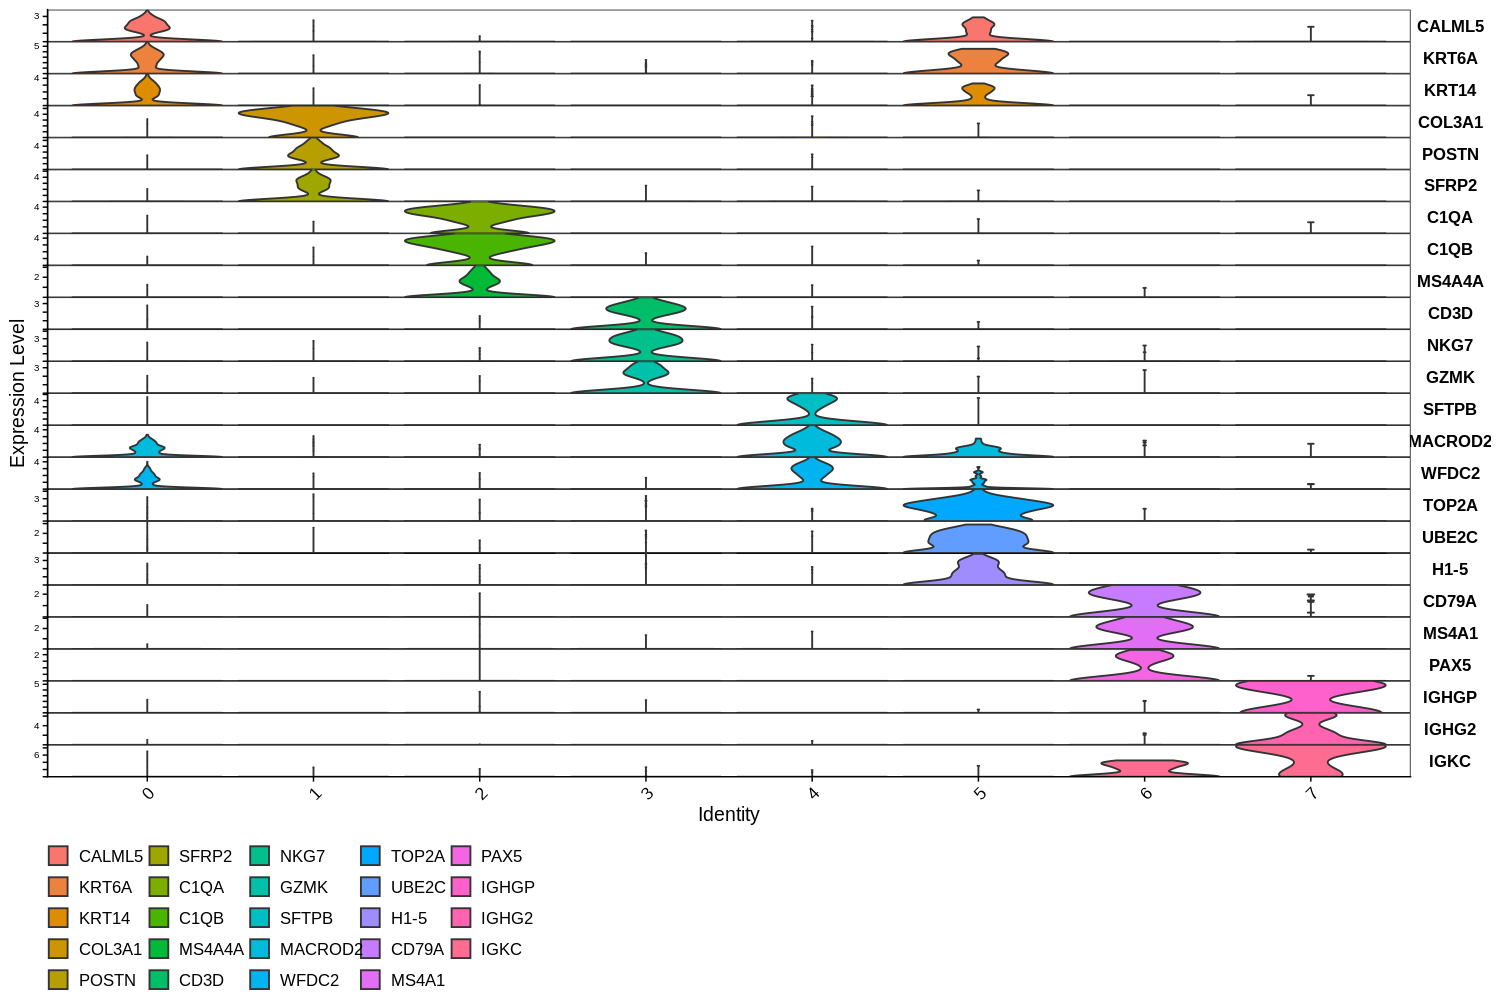

In [28]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
VlnPlot(obj40, features = c(top_3_genes$gene), layer = 'data', group.by = "seurat_clusters", pt.size = 0, stack = TRUE, flip = TRUE) + theme(legend.position = 'bottom')

In [29]:
devtools::install_github("satijalab/AzimuthAPI")

Warning message:
“`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.”



Rcpp       (1.1.1-1.1 -> 1.1.2    ) [CRAN]
xtable     (1.8-4     -> 1.8-8    ) [CRAN]
tinytex    (0.59      -> 0.60     ) [CRAN]
xfun       (0.58      -> 0.60     ) [CRAN]
openssl    (2.4.1     -> 2.4.2    ) [CRAN]
shiny      (1.13.0    -> 1.14.0   ) [CRAN]
findpython (NA        -> 1.0.9    ) [CRAN]
argparse   (NA        -> 2.3.1    ) [CRAN]
RCurl      (NA        -> 1.98-1.19) [CRAN]


Installing 9 packages: Rcpp, xtable, tinytex, xfun, openssl, shiny, findpython, argparse, RCurl

Installing packages into ‘/content/library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp1bgrPh/remotes5722f249c81/satijalab-AzimuthAPI-35be17a/DESCRIPTION’ ... OK
* preparing ‘AzimuthAPI’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘AzimuthAPI_0.2.0.tar.gz’



Installing package into ‘/content/library’
(as ‘lib’ is unspecified)



In [30]:
library(AzimuthAPI)

In [31]:
obj40 <- CloudAzimuth(obj40)

Running Pan-Human Azimuth on the cloud!

Uploading dataset



Uploading file and listening for updates...
File successfully uploaded 
Running ANNotate function...Running Pan-Human Azimuth: 
 
Reference model and parameters: 
Model name: M0.2 
Evaluation batch size: 40960 
Extract embeddings: True 
Run umap: False 
Refine labels in postprocessing: True 
Integer counts detected by panhumanpy.ANNotate : False 
Log-normalization performed by panhumanpy.ANNotate: False 
Query object: 
Total number of cells: 1868 
Total number of features: 4273 
Overlap w. feature reference: 4273 (~84%) 
 
Splitting query data into 1 evaluation batches. 
 
Running model: 
 
 1/59 ━━━━━━━━━━━━━━━━━━━━ 35s 604ms/step 
 9/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step    
19/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
29/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
39/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
49/

In [32]:
obj40@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,nCount_SCT,nFeature_SCT,sample,integrated_snn_res.0.4,seurat_clusters,silhouette_score,full_hierarchical_labels,final_level_labels,final_level_confidence,full_consistent_hierarchy,azimuth_broad,azimuth_medium,azimuth_fine,azimuth_label
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<chr>
AAACCCAAGTACAACA-1,1,21368.5062,5563,5.2828563,15.695680,3466,1633,preT,0,0,0.092996424,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.2265694,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAACCCACATCCGGCA-1,1,2185.0301,1247,4.4332051,15.481174,4023,1233,preT,6,6,0.276890213,Immune cell|Lymphoid cell|B cell|Memory B cell,Memory B cell,0.9669233,TRUE,Immune cell,B cell,Memory B cell,Memory B cell
AAACGAACAGGTGTGA-1,1,908.4158,597,5.4038361,22.289339,3441,660,preT,3,3,0.469265422,Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell|Memory CD8 T cell,Memory CD8 T cell,0.9824817,TRUE,Immune cell,T cell,GZMK CD8 T cell,Memory CD8 T cell
AAACGAAGTTCGTTCC-1,1,1209.6016,803,1.7431788,16.287654,3658,830,preT,3,3,0.297718122,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Memory CD4 T cell,Memory CD4 T cell,0.9350349,TRUE,Immune cell,T cell,Memory CD4 T cell,Memory CD4 T cell
AAAGAACTCCCATGGG-1,1,11959.1598,4019,5.6813659,16.286612,3585,1671,preT,0,0,-0.088038628,Epithelial cell,Epithelial cell,0.5487036,FALSE,False,False,False,Epithelial cell
AAAGAACTCGGTGTAT-1,1,1406.5290,790,3.5262480,28.195370,3654,790,preT,3,3,0.289982962,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Naive CD4 T cell,Naive CD4 T cell,0.4699603,FALSE,False,False,False,Naive CD4 T cell
AAAGGATCAAGTGGTG-1,1,10456.9103,3467,4.5589630,22.770045,3502,1418,preT,0,0,0.022799112,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.3455527,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGGCAGTGCAACG-1,1,22611.9056,5912,6.2437669,16.037617,3543,1765,preT,0,0,0.054652965,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.3826939,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGTAAGTTGCGCC-1,1,15341.5871,4030,6.9310925,25.275847,3883,1665,preT,0,0,0.095814736,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.2583768,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell


In [33]:
# remove cells with low scores
obj40_qc <- subset(obj40, final_level_confidence > 0.5)

In [34]:
# Use azimuth_embed as input Output a UMAP stored in azimuth_umap
obj40_qc <- RunUMAP(obj40_qc, dims = 1:128, reduction = "azimuth_embed", reduction.name = "azimuth_umap")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:39:13 UMAP embedding parameters a = 0.9922 b = 1.112

18:39:13 Read 1044 rows and found 128 numeric columns

18:39:13 Using Annoy for neighbor search, n_neighbors = 30

18:39:13 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:39:13 Writing NN index file to temp file /tmp/Rtmp1bgrPh/file5721aa48ad5

18:39:13 Searching Annoy index using 1 thread, search_k = 3000

18:39:14 Annoy recall = 100%

18:39:14 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

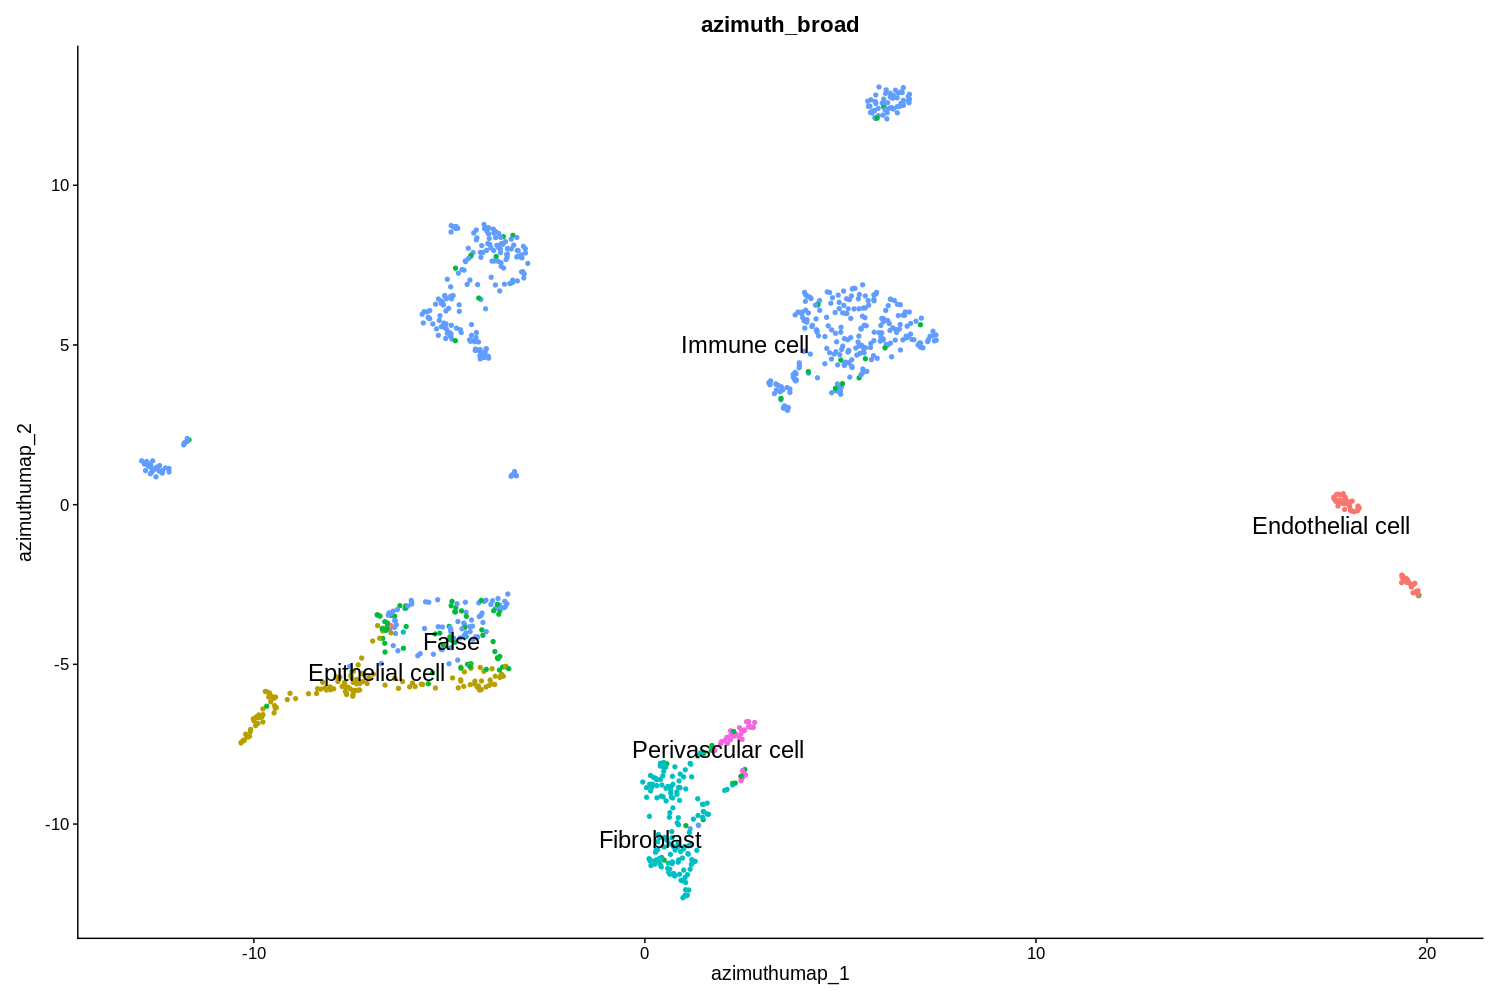

In [35]:
DimPlot(obj40_qc, group.by = "azimuth_broad", label.size = 6, label = T, reduction = "azimuth_umap",
    repel = TRUE) + NoLegend()

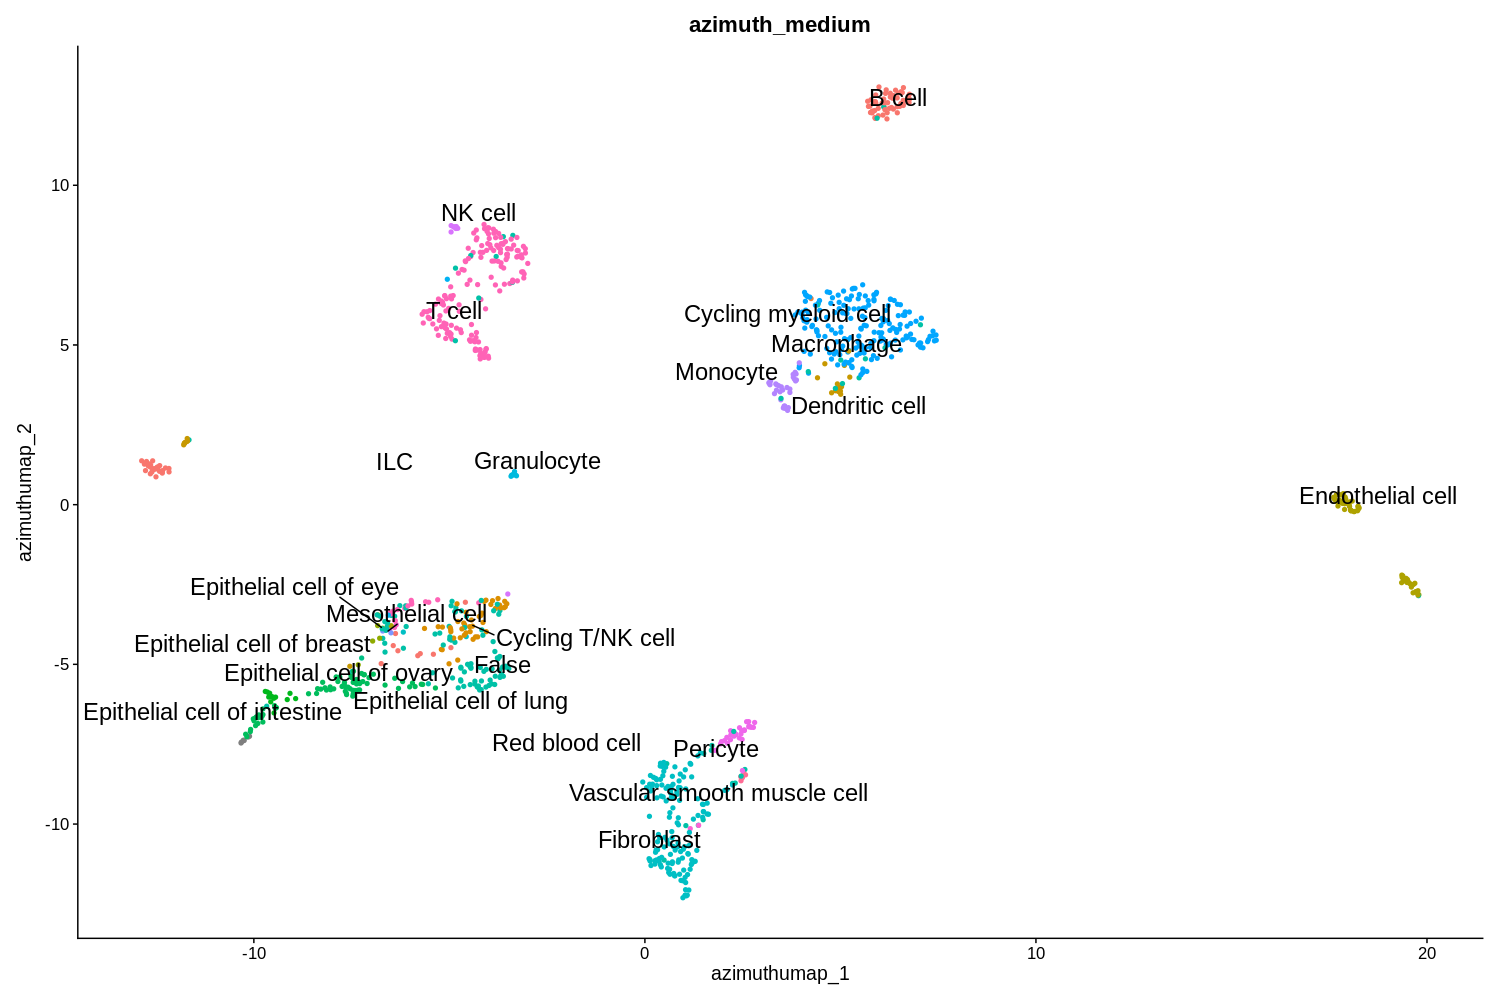

In [36]:
DimPlot(obj40_qc, group.by = "azimuth_medium", label.size = 6, label = T, reduction = "azimuth_umap",
    repel = TRUE) + NoLegend()

In [39]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] AzimuthAPI_0.2.0   ggplot2_4.0.3      patchwork_1.3.2    Seurat_5.5.1      
[5] SeuratObject_5.4.0 sp_2.2-1           dplyr_1.2.1       

loaded via a namespace (and not attac